In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.models as models

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [15]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

trainDir = "D:/SeniorProject/LLMImageLabels"
testDir = "D:/SeniorProject/CroppedImages"

trainDataset = ImageFolder(root=trainDir, transform=transform)
testDataset = ImageFolder(root=testDir, transform=transform)
trainLoader = DataLoader(trainDataset, batch_size=32, shuffle=True)
testLoader = DataLoader(testDataset, batch_size=32, shuffle=True)

In [27]:
def evaluateModel(model, testLoader):
  
  model.eval()
  correct = 0
  total = 0
  # Testing predictions on test set generated earlier and returning the accuracy
  with torch.no_grad():
    for images, labels in testLoader:
      images, labels = images.to(device), labels.to(device)
      outputs = model(images)
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()
  accuracy = 100 * correct / total
  return accuracy

In [28]:
def trainModel(model, numEpochs):
    
    testPath = "D:/SeniorProject/nbaValidation.pt"
    trainPath = "D:/SeniorProject/nbaTraining.pt"
    trainDataset= torch.load(trainPath, weights_only=False)
    testDataset = torch.load(testPath, weights_only=False)

    trainLoader = DataLoader(trainDataset, batch_size=32, shuffle=True)
    testLoader = DataLoader(testDataset, batch_size=32, shuffle=True)

    trainLosses = []
    trainAccuracies = []
    validLosses = []
    validAccuracies = []

    for epoch in range(numEpochs): 
        model.train()
        running_loss = 0.0
        correct = total = 0

        for i, data in enumerate(trainLoader, 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        trainLosses.append(running_loss / len(trainLoader))
        trainAccuracies.append(correct / total)

        model.eval()

        valLoss = 0
        correct = total = 0
        with torch.no_grad():
            for data in testLoader:
                images, labels = data
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                valLoss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        validLosses.append(valLoss / len(testLoader))
        validAccuracies.append(correct / total)
        print(f"Epoch {epoch + 1}/{numEpochs}, Train Loss: {trainLosses[-1]:.4f}, Train Accuracy: {trainAccuracies[-1]:.4f}, Validation Loss: {validLosses[-1]:.4f}, Validation Accuracy: {validAccuracies[-1]:.4f}")


    plt.plot(range(1, numEpochs + 1), trainLosses, label="Training Loss", color="blue")
    plt.plot(range(1, numEpochs + 1), validLosses, label="Validation Loss", color="orange")
    plt.plot(range(1, numEpochs + 1), validAccuracies, label="Validation Accuracy", color="green") # This is not working
    plt.xlabel("Epoch")
    plt.ylabel("Loss/Accuracy")
    plt.title("Statistics vs. Epochs")
    plt.legend()
    plt.show()
    
    return model

In [45]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5) 
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 53 * 53, 120)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 30)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

Epoch 1/10, Train Loss: 3.3330, Train Accuracy: 0.0675, Validation Loss: 3.4816, Validation Accuracy: 0.0330
Epoch 2/10, Train Loss: 3.0698, Train Accuracy: 0.1316, Validation Loss: 3.3326, Validation Accuracy: 0.0884
Epoch 3/10, Train Loss: 2.6199, Train Accuracy: 0.2409, Validation Loss: 3.2426, Validation Accuracy: 0.1030
Epoch 4/10, Train Loss: 2.2866, Train Accuracy: 0.3333, Validation Loss: 3.0606, Validation Accuracy: 0.1535
Epoch 5/10, Train Loss: 2.0130, Train Accuracy: 0.4259, Validation Loss: 3.1004, Validation Accuracy: 0.1555
Epoch 6/10, Train Loss: 1.7313, Train Accuracy: 0.4948, Validation Loss: 3.1959, Validation Accuracy: 0.1293
Epoch 7/10, Train Loss: 1.4050, Train Accuracy: 0.5912, Validation Loss: 3.4155, Validation Accuracy: 0.1652
Epoch 8/10, Train Loss: 1.0322, Train Accuracy: 0.7038, Validation Loss: 3.8082, Validation Accuracy: 0.1516
Epoch 9/10, Train Loss: 0.6495, Train Accuracy: 0.8109, Validation Loss: 4.2053, Validation Accuracy: 0.1545
Epoch 10/10, Train 

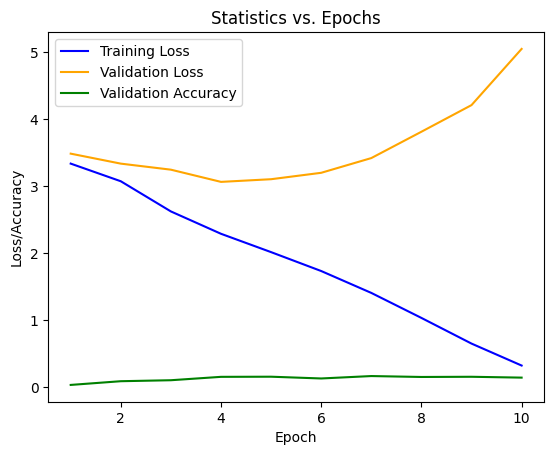

Accuracy: 14.188532555879494


In [53]:
model = Net().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
model = trainModel(model, 10)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy}")

In [39]:
class LeNet5(nn.Module):
        def __init__(self, num_classes):
            super(LeNet5, self).__init__()
            self.layer1 = nn.Sequential(
                nn.Conv2d(3, 6, kernel_size=5, stride=1, padding=0),
                nn.BatchNorm2d(6),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size = 2, stride = 2))
            self.layer2 = nn.Sequential(
                nn.Conv2d(6, 16, kernel_size=5, stride=3, padding=0),
                nn.BatchNorm2d(16),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size = 2, stride = 2))
            self.fc = nn.Linear(16 * 18 * 18, 120)
            self.relu = nn.ReLU()
            self.fc1 = nn.Linear(120, 84)
            self.relu1 = nn.ReLU()
            self.fc2 = nn.Linear(84, num_classes)
            
        def forward(self, x):
            out = self.layer1(x)
            out = self.layer2(out)
            out = out.reshape(out.size(0), -1)
            out = self.fc(out)
            out = self.relu(out)
            out = self.fc1(out)
            out = self.relu1(out)
            out = self.fc2(out)
            return out

Epoch 1/20, Train Loss: 2.7777, Train Accuracy: 0.2071, Validation Loss: 2.9124, Validation Accuracy: 0.1467
Epoch 2/20, Train Loss: 2.2514, Train Accuracy: 0.3384, Validation Loss: 2.8046, Validation Accuracy: 0.1701
Epoch 3/20, Train Loss: 1.9047, Train Accuracy: 0.4344, Validation Loss: 2.7026, Validation Accuracy: 0.2138
Epoch 4/20, Train Loss: 1.6093, Train Accuracy: 0.5220, Validation Loss: 2.9495, Validation Accuracy: 0.1856
Epoch 5/20, Train Loss: 1.3365, Train Accuracy: 0.6039, Validation Loss: 2.8869, Validation Accuracy: 0.1953
Epoch 6/20, Train Loss: 1.0671, Train Accuracy: 0.6858, Validation Loss: 3.2022, Validation Accuracy: 0.1992
Epoch 7/20, Train Loss: 0.8307, Train Accuracy: 0.7514, Validation Loss: 3.1226, Validation Accuracy: 0.2284
Epoch 8/20, Train Loss: 0.6283, Train Accuracy: 0.8091, Validation Loss: 3.4430, Validation Accuracy: 0.2070
Epoch 9/20, Train Loss: 0.4302, Train Accuracy: 0.8730, Validation Loss: 3.6304, Validation Accuracy: 0.2099
Epoch 10/20, Train 

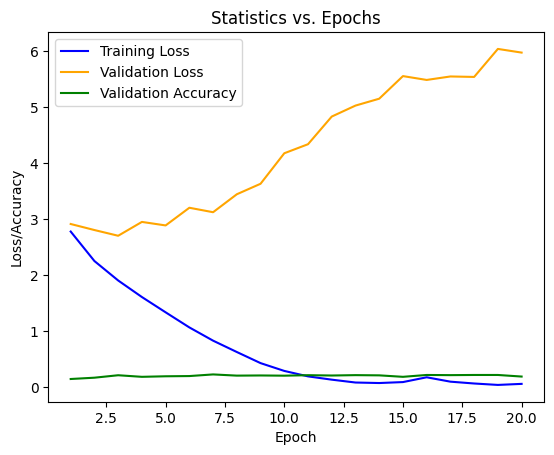

Accuracy: 19.0476%


In [41]:
model = LeNet5(30).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model = trainModel(model, 20)
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy:.4f}%")

Epoch 1/30, Train Loss: 2.7207, Train Accuracy: 0.2062, Validation Loss: 2.8980, Validation Accuracy: 0.1652
Epoch 2/30, Train Loss: 2.2318, Train Accuracy: 0.3345, Validation Loss: 2.6558, Validation Accuracy: 0.2089
Epoch 3/30, Train Loss: 1.9494, Train Accuracy: 0.4188, Validation Loss: 2.5324, Validation Accuracy: 0.2507
Epoch 4/30, Train Loss: 1.7055, Train Accuracy: 0.4838, Validation Loss: 2.2627, Validation Accuracy: 0.3372
Epoch 5/30, Train Loss: 1.5066, Train Accuracy: 0.5385, Validation Loss: 2.5679, Validation Accuracy: 0.2886
Epoch 6/30, Train Loss: 1.3271, Train Accuracy: 0.6006, Validation Loss: 2.1110, Validation Accuracy: 0.3907
Epoch 7/30, Train Loss: 1.1408, Train Accuracy: 0.6577, Validation Loss: 2.1799, Validation Accuracy: 0.4101
Epoch 8/30, Train Loss: 0.9963, Train Accuracy: 0.7034, Validation Loss: 1.9842, Validation Accuracy: 0.4791
Epoch 9/30, Train Loss: 0.8538, Train Accuracy: 0.7427, Validation Loss: 1.7666, Validation Accuracy: 0.5102
Epoch 10/30, Train 

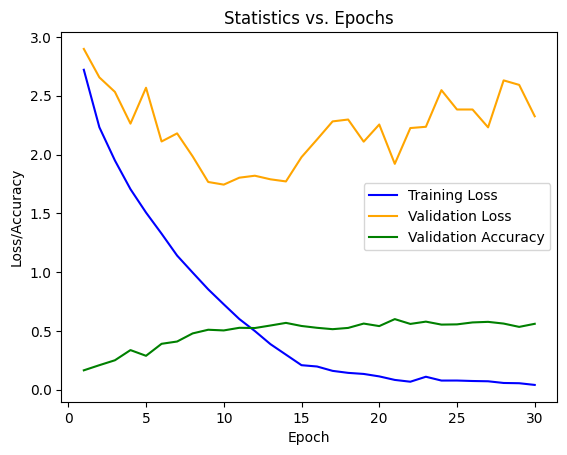

Accuracy: 56.0739%


In [44]:
model = models.resnet18()
model.fc = nn.Linear(512, 30)
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = trainModel(model, 30)
print(f"Accuracy: {evaluateModel(model, testLoader):.4f}%")